Requests for Data

In [1]:
# System
import os
import glob as glob


# Basic Function
import pandas as pd
import numpy as np

# Visuals
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import seaborn as sns


### Statistics Packages ###

from statsmodels.stats.outliers_influence import variance_inflation_factor #VIF

# Requisite Functionality 
from sklearn.model_selection import train_test_split
import statsmodels.api

# Linear Regression
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LinearRegression

# Time Series
import statsmodels.tsa as tsa
from statsmodels.graphics.tsaplots import month_plot





#Location (GPS,GIS,GDF)
import geopandas as gpd
from shapely.geometry import Point # for gpd/GIS
###import requests


pd.set_option('display.max_columns', None)

In [ ]:
os.chdir('.\\2024 Hillsborough Shape Files')

In [ ]:
os.listdir()

In [272]:
coastal_permits=pd.read_csv('Coastal_Permit_Activities.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'Coastal_Permit_Activities.csv'

In [ ]:
coastal_permits.head()

In [ ]:
coastal_permits.info()

In [ ]:
coastal_permits.LATITUDE

In [ ]:
gdf = gpd.GeoDataFrame(coastal_permits, geometry=gpd.points_from_xy(coastal_permits['longitude'], coastal_permits['latitude']))

In [ ]:
gdf.describe

In [ ]:
gdf.plot()

In [ ]:
coastal_permits

In [ ]:
gdf_shp=gpd.read_file('2024_10_parcels.shp')

In [ ]:
gdf_shp.head()

In [ ]:
gdf_shp.plot()

In [ ]:
coastal_permits_gdf = gpd.GeoDataFrame(coastal_permits, geometry=gpd.points_from_xy(coastal_permits['longitude'], coastal_permits['latitude']))

In [ ]:
gdf.plot(column='population', cmap='YlOrRd', legend=True, figsize=(20, 20))

In [ ]:
coastal_permits_gdf.head()

In [ ]:
coastal_permits_gdf.head(1)

In [ ]:
gdf_shp

In [ ]:
import geopandas as gpd
import pandas as pd

def extract_coordinates(gdf):
  """Extracts latitude and longitude from a GeoDataFrame with polygons and multipolygons"""

  coordinates = []
  for index, row in gdf.iterrows():
    geom = row['geometry']
    if geom.type == 'Polygon':
      for coord in geom.exterior.coords:
        coordinates.append(coord)
    elif geom.type == 'MultiPolygon':
      for polygon in geom:
        for coord in polygon.exterior.coords:
          coordinates.append(coord)
    else:
      print(f"Unsupported geometry type: {geom.type}")
  return coordinates

# Assuming 'gdf' is your GeoDataFrame
all_coordinates = extract_coordinates(gdf_shp)

# Create a Pandas DataFrame from the extracted coordinates
df = pd.DataFrame(all_coordinates, columns=['longitude', 'latitude'])

print(df.head())

In [ ]:
def extract_coordinates(gdf_shp):
  """Extracts latitude and longitude from a GeoDataFrame with MultiPolygon geometries"""

  coordinates = []
  for index, row in gdf_shp.iterrows():
    for polygon in row['geometry']:
      for coord in polygon.exterior.coords:
        coordinates.append(coord)
  return coordinates

all_coordinates = extract_coordinates(gdf)

In [ ]:
coastal_permits_gdf

In [ ]:
X=gdf_shp.geometry.to_crs(4326)

In [ ]:
coastal_permits.head(10)

In [ ]:
X

In [ ]:
coastal_permits_gdf.head(1)

## gdf_shp.head(1)

In [ ]:
gdf_shp.geometry.crs

In [ ]:
coastal_permits_gdf.geometry

In [ ]:
gdf_shp.geometry

In [ ]:
gdf_melt=pd.melt(gdf_shp)

In [ ]:
gdf_geo=gdf_melt[gdf_melt['variable']=='geometry']

In [ ]:
gdf_shp.index

In [ ]:
coastal_permits_gdf

In [ ]:
pl
pd.concat([gdf_shp.geometry,coastal_permits_gdf.geometry]).plot()
plt.show

In [ ]:
coastal_permits_gdf.info()

In [ ]:
gdf.to_file('coastal_permits_gdf', driver='GeoJSON')  

In [ ]:
coastal_permits_gdf.to_file('./' ,driver='JSON')

In [ ]:
pwd

In [ ]:
coastal_permits_gdf.geometry=coastal_permits_gdf.geometry.set_crs(4326)

In [ ]:
coastal_permits_gdf.to_file('.\\test',driver='GeoJSON')

In [240]:
gdf_shp.to_csv('hc_shp.csv')

In [ ]:
gdf_shp.Edit_dt=pd.to_datetime(gdf_shp.Edit_dt)

In [29]:
gdf_shp

NameError: name 'gdf_shp' is not defined

In [237]:
gdf_shp.columns = gdf_shp.columns.str.lower()

In [243]:
coastal_permits_gdf

,x,y,objectid,file_id,county,prmt_typ,prmt_num,status,des_code,descript,rng_from,rng_to,datum,sp_zone,east,north,latitude,longitude,ver_stat,iss_date,exp_date,own_last,frst_loc,pnt_prox,const_st,src,datum_desc_spc,proximity_id,accuracy_id,accuracy_desc,geometry
0,228249.499782,685295.191479,1,7509,BA,CCCL,BA000001,Closed,64,"Decks, Porches, and Balconies attached to Majo...",BA R-075,NaN,NAD83,NORTH,1562322.10,425493.54,30.163698,85.785326,NOT REVIEWED,19810424,19820424.0,"Horaitis, Kostas and Maria K.","8109 Surf Drive, Panama City Beach",Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,5,21-50,POINT (85.78533 30.1637)
1,230679.030418,683254.001625,2,7510,BA,CCCL,BA000002,Closed,34,Fill,BA R-085,NaN,NAD83,NORTH,1570324.50,418831.05,30.145625,85.759772,NOT REVIEWED,19800313,19810913.0,NaN,"Thomas Drive, Panama City Beach",Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,5,21-50,POINT (85.75977 30.14562)
2,230679.030418,683254.001625,3,7510,BA,CCCL,BA000002,Closed,64,"Decks, Porches, and Balconies attached to Majo...",BA R-085,NaN,NAD83,NORTH,1570324.50,418831.05,30.145625,85.759772,NOT REVIEWED,19800313,19810913.0,NaN,"Thomas Drive, Panama City Beach",Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,5,21-50,POINT (85.75977 30.14562)
3,230679.030418,683254.001625,4,7510,BA,CCCL,BA000002,Closed,82,"Walkways, Boardwalks And/Or Stairs",BA R-085,NaN,NAD83,NORTH,1570324.50,418831.05,30.145625,85.759772,NOT REVIEWED,19800313,19810913.0,NaN,"Thomas Drive, Panama City Beach",Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,5,21-50,POINT (85.75977 30.14562)
4,264531.549199,659904.150665,5,7511,BA,CCCL,BA000003,Closed,1,Single Family Dwelling,BA R-136,NaN,NAD83,NORTH,1681792.56,342700.04,29.939205,85.405208,NOT REVIEWED,19800723,19820123.0,"Kohler, Keith","U.S. Highway 98, Mexico Beach",Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,5,21-50,POINT (85.40521 29.9392)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140507,694779.967651,574756.075031,140508,74505,VO,JCP,0312780-002-JC,Issued,3,"Public or Commercial (Hotel, Restaurant, Offic...",VO R-118,NaN,NAD83,EAST,667502.13,1749590.16,29.146581,80.964489,REVIEWED,20151124,20201124.0,"Barshay, Raymond E.","3701 S. Atlantic Avenue, Daytona Beach Shores",Exact feature location,NaN,L,North American Datum Of 1983,EXACT,3,1.1-10,POINT (80.96449 29.14658)
140508,192039.484951,704193.259883,140509,17999,WL,JCP,0127254-001-JC,Closed,85,Excavation,WL R-072,NaN,NAD83,NORTH,1443192.16,487054.68,30.328717,86.165103,NOT REVIEWED,19970818,19980430.0,"Butler, Van Ness",Grayton Beach,Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,6,50-999.99,POINT (86.1651 30.32872)
140509,206642.925780,698113.108983,140510,42215,WL,JCP,0202472-002-JC,Issued,23,Groin,WL R-122,WL R-124,NAD83,NORTH,1491217.79,467273.27,30.276171,86.012060,REVIEWED,20040525,20090525.0,"Pickel, Bradley",Inlet Beach,Exact feature location,NaN,M,North American Datum Of 1983,EXACT,1,0-.01,POINT (86.01206 30.27617)
140510,207219.309346,697869.387843,140511,42215,WL,JCP,0202472-002-JC,Issued,23,Groin,WL R-122,WL R-124,NAD83,NORTH,1493113.48,466480.40,30.274060,86.006022,REVIEWED,20040525,20090525.0,"Pickel, Bradley",Inlet Beach,Exact feature location,NaN,M,North American Datum Of 1983,EXACT,1,0-.01,POINT (86.00602 30.27406)


In [250]:
coastal_permits_gdf

,x,y,objectid,file_id,county,prmt_typ,prmt_num,status,des_code,descript,rng_from,rng_to,datum,sp_zone,east,north,latitude,longitude,ver_stat,iss_date,exp_date,own_last,frst_loc,pnt_prox,const_st,src,datum_desc_spc,proximity_id,accuracy_id,accuracy_desc,geometry
0,228249.499782,685295.191479,1,7509,BA,CCCL,BA000001,Closed,64,"Decks, Porches, and Balconies attached to Majo...",BA R-075,NaN,NAD83,NORTH,1562322.10,425493.54,30.163698,85.785326,NOT REVIEWED,19810424,19820424.0,"Horaitis, Kostas and Maria K.","8109 Surf Drive, Panama City Beach",Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,5,21-50,POINT (85.78533 30.1637)
1,230679.030418,683254.001625,2,7510,BA,CCCL,BA000002,Closed,34,Fill,BA R-085,NaN,NAD83,NORTH,1570324.50,418831.05,30.145625,85.759772,NOT REVIEWED,19800313,19810913.0,NaN,"Thomas Drive, Panama City Beach",Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,5,21-50,POINT (85.75977 30.14562)
2,230679.030418,683254.001625,3,7510,BA,CCCL,BA000002,Closed,64,"Decks, Porches, and Balconies attached to Majo...",BA R-085,NaN,NAD83,NORTH,1570324.50,418831.05,30.145625,85.759772,NOT REVIEWED,19800313,19810913.0,NaN,"Thomas Drive, Panama City Beach",Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,5,21-50,POINT (85.75977 30.14562)
3,230679.030418,683254.001625,4,7510,BA,CCCL,BA000002,Closed,82,"Walkways, Boardwalks And/Or Stairs",BA R-085,NaN,NAD83,NORTH,1570324.50,418831.05,30.145625,85.759772,NOT REVIEWED,19800313,19810913.0,NaN,"Thomas Drive, Panama City Beach",Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,5,21-50,POINT (85.75977 30.14562)
4,264531.549199,659904.150665,5,7511,BA,CCCL,BA000003,Closed,1,Single Family Dwelling,BA R-136,NaN,NAD83,NORTH,1681792.56,342700.04,29.939205,85.405208,NOT REVIEWED,19800723,19820123.0,"Kohler, Keith","U.S. Highway 98, Mexico Beach",Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,5,21-50,POINT (85.40521 29.9392)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140507,694779.967651,574756.075031,140508,74505,VO,JCP,0312780-002-JC,Issued,3,"Public or Commercial (Hotel, Restaurant, Offic...",VO R-118,NaN,NAD83,EAST,667502.13,1749590.16,29.146581,80.964489,REVIEWED,20151124,20201124.0,"Barshay, Raymond E.","3701 S. Atlantic Avenue, Daytona Beach Shores",Exact feature location,NaN,L,North American Datum Of 1983,EXACT,3,1.1-10,POINT (80.96449 29.14658)
140508,192039.484951,704193.259883,140509,17999,WL,JCP,0127254-001-JC,Closed,85,Excavation,WL R-072,NaN,NAD83,NORTH,1443192.16,487054.68,30.328717,86.165103,NOT REVIEWED,19970818,19980430.0,"Butler, Van Ness",Grayton Beach,Offset to exact feature location,Completed in Compliance,L,North American Datum Of 1983,OFFST,6,50-999.99,POINT (86.1651 30.32872)
140509,206642.925780,698113.108983,140510,42215,WL,JCP,0202472-002-JC,Issued,23,Groin,WL R-122,WL R-124,NAD83,NORTH,1491217.79,467273.27,30.276171,86.012060,REVIEWED,20040525,20090525.0,"Pickel, Bradley",Inlet Beach,Exact feature location,NaN,M,North American Datum Of 1983,EXACT,1,0-.01,POINT (86.01206 30.27617)
140510,207219.309346,697869.387843,140511,42215,WL,JCP,0202472-002-JC,Issued,23,Groin,WL R-122,WL R-124,NAD83,NORTH,1493113.48,466480.40,30.274060,86.006022,REVIEWED,20040525,20090525.0,"Pickel, Bradley",Inlet Beach,Exact feature location,NaN,M,North American Datum Of 1983,EXACT,1,0-.01,POINT (86.00602 30.27406)


In [3]:
coastal_permits[coastal_permits.frst_loc.str. contains('Apollo')]

NameError: name 'coastal_permits' is not defined

In [258]:
coastal_permits.fillna(0,inplace=True)

In [4]:
coastal_permits[mask]

NameError: name 'coastal_permits' is not defined

In [295]:
coastal_permits.longitude

0        -85.785326
1        -85.759772
2        -85.759772
3        -85.759772
4        -85.405208
            ...    
140507   -80.964489
140508   -86.165103
140509   -86.012060
140510   -86.006022
140511   -86.174507
Name: longitude, Length: 140512, dtype: float64

In [294]:
coastal_permits.longitude=coastal_permits.longitude*-1

In [298]:
coastal_permits.to_csv('coastcoastal_permits_fix.csv')

In [4]:
pwd

'J:\\Brainstation\\Capstone Git\\Apollo_Beach_Model - Copy\\notebooks'

In [6]:
os.chdir('J:\\Brainstation\\Capstone Git\\data\\human Imact\\2024 Hillsborough Shape Files')

In [7]:
dev=gpd.read_file('Tampa_Bay_Development.shp')

In [8]:
dev_df=pd.read_csv('hc_shp.csv',encoding='cp1252',low_memory=False)

In [11]:
dev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525601 entries, 0 to 525600
Data columns (total 49 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  525601 non-null  int64  
 1   folio       525600 non-null  object 
 2   type        1 non-null       object 
 3   edit_dt     525601 non-null  object 
 4   pin         522022 non-null  object 
 5   dor_c       525250 non-null  object 
 6   owner       525246 non-null  object 
 7   addr_1      521994 non-null  object 
 8   addr_2      22336 non-null   object 
 9   city        521700 non-null  object 
 10  state       520100 non-null  object 
 11  zip         520118 non-null  object 
 12  country     1610 non-null    object 
 13  sub         522022 non-null  object 
 14  site_addr   522022 non-null  object 
 15  site_city   520513 non-null  object 
 16  site_zip    520205 non-null  object 
 17  legal1      522022 non-null  object 
 18  legal2      518368 non-null  object 
 19  le

In [12]:
dev_df.head(10)

,Unnamed: 0,folio,type,edit_dt,pin,dor_c,owner,addr_1,addr_2,city,state,zip,country,sub,site_addr,site_city,site_zip,legal1,legal2,legal3,legal4,dba,strap,tbeds,tbaths,tstories,tunits,tbldgs,taxdist,just,land,bldg,exf,act,eff,heat_ar,asd_val,tax_val,muni,sd1,sd2,tif,base,s_date,vi,s_amt,acreage,nbhc,geometry
0,0,0000010000,NaN,2019-04-08,A-23-33-15-ZZZ-000000-00020.0,8800,UNITED STATES,EGMONT KEY STATE PARK,4905 34TH ST S PMB 5000,SAINT PETERSBURG,FL,33711-4511,NaN,ZZZ,0 EGMONT KEY,ST PETERSBURG,33715,23 24 25 AND 26-33-15,THAT ISLAND KNOWN AS EGMONT KEY DESC AS GOVT LOTS,1 2 & 3 IN SEC 23-33-15 GOVT LOT 1 IN SEC 24-3...,GOV LOT 1 IN SEC 25-33-15 & GOV LOTS 1 & 2 IN SEC,EGMONT KEY ISLAND,153323ZZZ000000000200A,0.0,0.0,0.0,0.0,0.0,TA,7447118.0,7341138.0,0.0,105980.0,0,0,0.0,6165623.0,0.0,A,NaN,NaN,NaN,0,0000/00/00,NaN,0.0,313.011000,227002.0,POLYGON ((409857.8100275807 1183358.9587720707...
1,1,0000050000,NaN,2019-04-08,A-23-33-15-ZZZ-000000-00040.0,8600,HILLSBOROUGH COUNTY,REAL ESTATE DEPT,PO BOX 1110,TAMPA,FL,33601-1110,NaN,ZZZ,0,ST PETERSBURG,33715,THAT PART OF GOVT LOT 1 DESC AS LYING S 2 DEG 34,MIN 04 SEC W 5226 FT FROM CENTER OF EGMONT,LIGHTHOUSE SAID CENTER BEING LAT 27 DEG 36 MIN,01.980 SEC LONG 82 DEG 45 MIN 39.003 SEC AND RUN,EGMONT KEY,153323ZZZ000000000400A,0.0,0.0,0.0,0.0,0.0,TA,322675.0,230175.0,0.0,92500.0,0,0,0.0,280899.0,0.0,A,NaN,NaN,NaN,0,0000/00/00,NaN,0.0,6.147920,227002.0,"POLYGON ((409830.3255024962 1182759.687988989,..."
2,2,0000080000,NaN,2019-04-09,U-01-27-17-001-000000-00001.0,0000,PAULINE L SEVIGNY/ LIFE ESTATE,19931 ANGEL LN,NaN,ODESSA,FL,33556-3919,NaN,001,19931 ANGEL LN,ODESSA,33556,KEYSTONE PARK COLONY,A PORTION OF TRACT 1 IN NE 1/4 OF SEC 1 DESC AS:,COM AT NW COR OF TRACT 1 S 89 DEG 16 MIN 05 SEC E,603.85 FT TO NE COR S 01 DEG 47 MIN 49 SEC E,NaN,172701001000000000010U,0.0,0.0,0.0,0.0,0.0,U,256872.0,210327.0,0.0,46545.0,0,0,0.0,240014.0,240014.0,U,NaN,NaN,NaN,0,0000/00/00,NaN,0.0,4.713410,211007.0,POLYGON ((477742.84879791364 1395939.164844408...
3,3,0000080100,NaN,2019-04-09,U-01-27-17-001-000000-00001.1,0100,JEFFERY AND PATRICIA SEVIGNY,19859 ANGEL LN,NaN,ODESSA,FL,33556-3917,NaN,001,19859 ANGEL LN,ODESSA,33556,KEYSTONE PARK COLONY,TRACT 1 IN NE 1/4 LESS N 200 FT THEREOF LESS THE,COM AT NW COR OF TRACT 1 S 01 DEG 36 MIN 23 SEC E,339.93 FT FOR POB N 88 DEG 51 MIN 52 SEC E 604.43,NaN,172701001000000000011U,3.0,2.0,2.0,1.0,1.0,U,634852.0,217757.0,410323.0,6772.0,1996,2010,2617.0,457046.0,407046.0,U,NaN,NaN,NaN,2016,1987/08/01,I,50000.0,5.058780,211007.0,POLYGON ((477173.2600420788 1395264.7849595696...
4,4,0000090000,NaN,2019-04-09,U-01-27-17-001-000000-00002.0,0100,MARIETTA SHIVER LIFE ESTATE,19901 ANGEL LN,NaN,ODESSA,FL,33556-3919,NaN,001,19901 ANGEL LN,ODESSA,33556,KEYSTONE PARK COLONY,S 210 OF W 225 FT OF TRACT 2 IN NE 1/4 LESS W 15,FT FOR R/W,NaN,NaN,172701001000000000020U,2.0,1.0,1.0,1.0,1.0,U,248877.0,94435.0,141733.0,12709.0,1973,1998,1619.0,136288.0,0.0,U,NaN,NaN,NaN,1994,0000/00/00,NaN,0.0,1.000590,211007.0,"POLYGON ((477172.840095412 1395282.3951605707,..."
5,5,0000090100,NaN,2019-04-09,U-01-27-17-001-000000-00002.1,0100,JASEN T AND CHRISTINA J KEYES,19913 ANGEL LN,NaN,ODESSA,FL,33556-3919,NaN,001,19913 ANGEL LN,ODESSA,33556,KEYSTONE PARK COLONY,N 322.24 FT OF TRACT 2 IN NE 1/4 LESS W 15 FT FOR,RD R/W,NaN,NaN,172701001000000000021U,3.0,2.5,1.0,1.0,1.0,U,561255.0,339615.0,204890.0,16750.0,1976,2009,1572.0,561255.0,511255.0,U,NaN,NaN,NaN,2024,2021/10/27,I,750000.0,4.438490,211007.0,POLYGON ((477751.2496997453 1395608.5752824917...
6,6,0000090200,NaN,2019-04-09,U-01-27-17-001-000000-00002.2,0000,IRENE K MCKINNEY / LIFE ESTATE,10036 LAKE OAK CIR,NaN,TAMPA,FL,33624-5288,NaN,001,19907 ANGEL LN,ODESSA,33556,KEYSTONE PARK COLONY,TRACT 2 IN NE 1/4 LESS S 210 FT OF W 225 FT AND,LESS N 322.24 FT AND LESS W 15 FT FOR RD R/W,NaN,NaN,172701001000000000022U,0.0,0.0,0.0,0.0,0.0,U,292998.0,286344.0,0.0,6654.0,0,0,0.0,259632.0,259632.0,U,NaN,NaN,NaN,0,2000/02/03,V,100000.0,3.498560,211007.0,POLYGON ((47

In [22]:
pwd

'J:\\Brainstation\\Capstone Git\\data\\human Imact\\2024 Hillsborough Shape Files'

<Figure size 5000x5000 with 0 Axes>

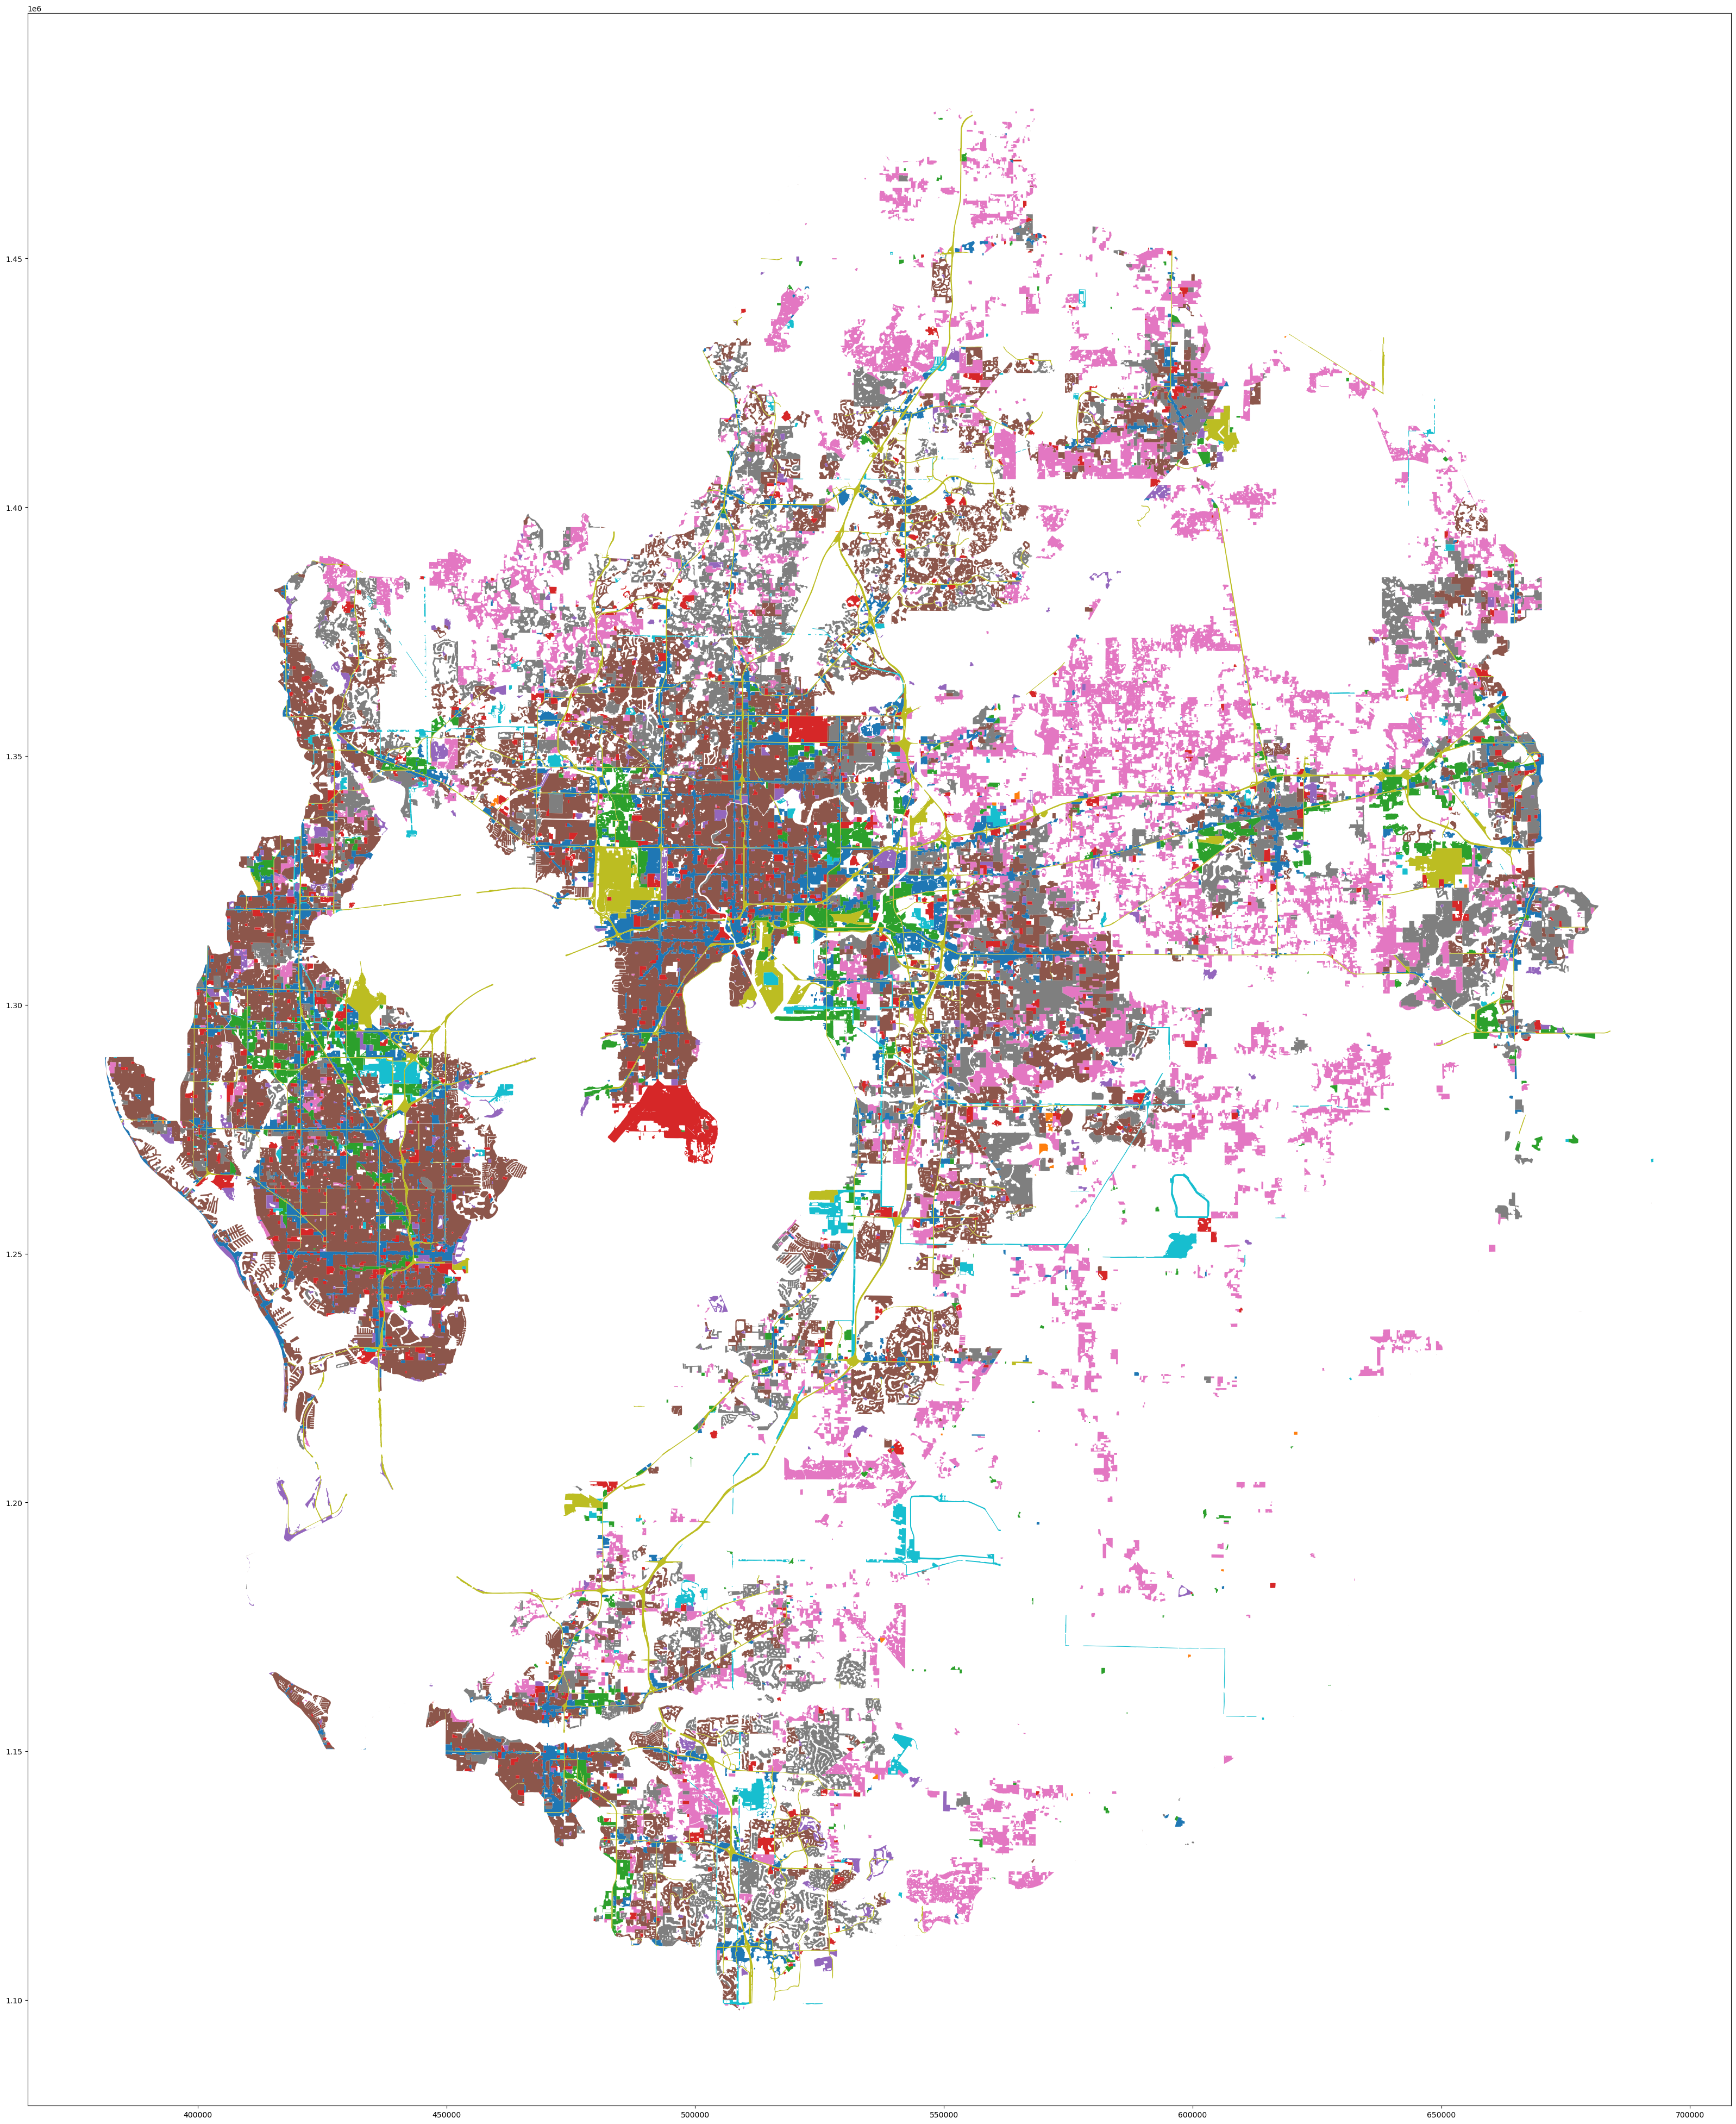

In [27]:
plt.figure(figsize=(50,50))
dev.plot(column='FLUCSDESC',figsize=(50,50))
#plt.plot(dev)
#plt.legend()
plt.savefig('test.png')
plt.show()


In [ ]:
# Calculate the nearest neighbor for each point
nearest_neighbors = dev.sjoin_nearest(dev, how="left")

# Calculate the distance to the nearest neighbor
nearest_neighbors['distance'] = nearest_neighbors.apply(lambda row: row['geometry'].distance(row['index_right']), axis=1)

# Calculate the KDE based on the distance to the nearest neighbor
kde = gaussian_kde(nearest_neighbors['distance'])

# You can then use the kde object to calculate density values for specific distances

In [6]:
import geopandas as gpd
from shapely.geometry import Polygon, box

# Read in the shapefile of Hillsborough County
county_shapefile = dev

# Get the bounding box of the county
bbox = county_shapefile.geometry.union()

# Define the grid size (adjust as needed)
grid_size = 0.01  # degrees

# Create a list of polygons for the grid
grid_cells = []
for x in np.arange(bbox[0], bbox[2], grid_size):
    for y in np.arange(bbox[1], bbox[3], grid_size):
        cell = Polygon([(x, y), (x + grid_size, y), (x + grid_size, y + grid_size), (x, y + grid_size)])
        grid_cells.append(cell)

# Create a GeoDataFrame from the grid cells
grid = dev.GeoDataFrame({'geometry': grid_cells})
grid.crs = county_shapefile.crs

NameError: name 'dev' is not defined

In [5]:
os.chdir('J:\\Brainstation\\Capstone Git\\data\\human Imact\\Population Data')

In [6]:
pop_metro=pd.read_csv('tampa_metro_population.csv',header=0)

In [7]:
pop_metro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 54 non-null     int64  
 1   Population                           54 non-null     int64  
 2           Index                        54 non-null     float64
 3           Percent Change               54 non-null     object 
 4           Percent of Statewide Total   54 non-null     float64
 5           Percent of Nationwide Total  54 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 2.7+ KB


In [8]:
pop_metro

,Year,Population,Index,Percent Change,Percent of Statewide Total,Percent of Nationwide Total
0,1969,483694,100.000000,N,7.283451,0.240288
1,1970,493409,102.008501,2.008501243,7.207941,0.242106
2,1971,513136,106.086906,3.998102994,7.163676,0.248111
3,1972,533386,110.273437,3.946322223,7.092593,0.254873
4,1973,564604,116.727518,5.852797036,7.122454,0.267143
5,1974,586558,121.266338,3.88838903,7.052490,0.274949
6,1975,593254,122.650684,1.141575087,6.945418,0.275347
7,1976,601762,124.409647,1.434124338,6.920499,0.276604
8,1977,607712,125.639764,0.988762999,6.836707,0.276533
9,1978,620076,128.195925,2.03451635,6.790476,0.279190


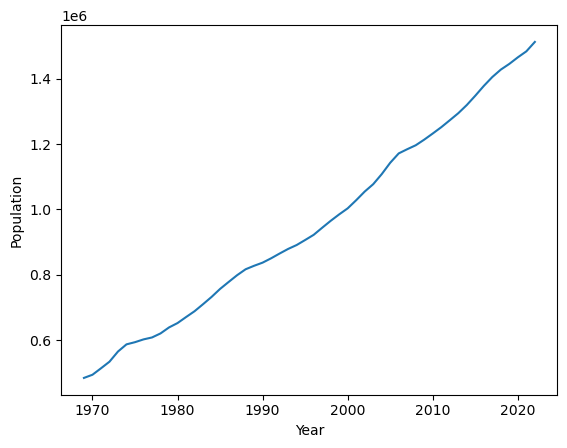

In [16]:
sns.lineplot(x='Year',y='Population',data=pop_metro)
plt.xlabel='year'
plt.ylabel='Population'

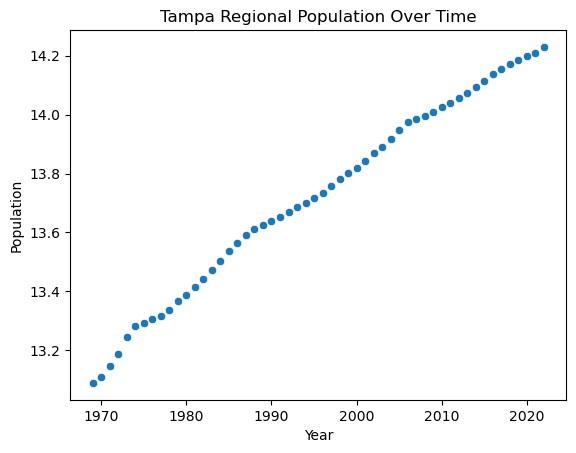

In [19]:

sns.scatterplot(x='Year',y=np.log(pop_metro.Population),data=pop_metro)
plt.set_xlabel='Population (per 100k)'
plt.title('Tampa Regional Population Over Time')
plt.show()

In [20]:
LinRegLog=LinearRegression()

In [21]:
X=pop_metro.Year.to_frame()
y=pop_metro.Population

In [23]:
LinRegLog.fit(X,y)

LinearRegression()

In [26]:
LinRegLog.score(X,y)

0.992766818417056

In [27]:
LinRegLog.coef_

array([19270.39142367])

In [ ]:
LinRegLog.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
LinRegLog.fit(X_train,y_train)

LinearRegression()

In [28]:
LinRegLog.score(X_train,y_train)

0.9923543099620151

In [29]:
LinRegLog.score(X_test,y_test)

0.9934046470995561

In [3]:
pwd

'J:\\Brainstation\\BS Git\\Tampa_Apollo_AnthropogenicIndex\\notebooks'

In [4]:
os.chdir('J:\\Brainstation\\BS Git\\Property Records\\GIS\\Zips\\')

### IMPORT ALL PROPERTY RECORDS JOIN GPS